In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import time

print("\n[0.1] DOWNLOADING DATASET")
print("-" * 40)

# Dataset URL
DATASET_URL = "https://www.dropbox.com/scl/fi/2jibh9twr8jml97mqtyki/churn_uplift_anonymized.csv?rlkey=907ib1npo2a9zk27ot5ra6zsg&dl=1"

# Create data directory
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)
data_path = data_dir / "churn_uplift_anonymized.csv"

# Download dataset
try:
    if not data_path.exists():
        print(f"Downloading dataset from Dropbox...")
        import urllib.request
        urllib.request.urlretrieve(DATASET_URL, data_path)
        print(f"Dataset downloaded to: {data_path}")
    else:
        print(f"Dataset already exists at: {data_path}")
except Exception as e:
    print(f"Could not download automatically: {e}")
    print("\nPlease download manually:")
    print(f"1. Visit: {DATASET_URL}")
    print(f"2. Save as: {data_path}")
    print("\nThen run the script again.")
    # Don't raise - allow manual download


[0.1] DOWNLOADING DATASET
----------------------------------------
Dataset already exists at: data\churn_uplift_anonymized.csv


In [4]:
# Standard libraries
from scipy import stats

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_curve, auc
)
from sklearn.ensemble import RandomForestClassifier

# Gradient Boosting (PDF Requirement)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Uplift Modeling (Uber's CausalML - PDF Requirement)
from causalml.inference.meta import BaseTRegressor, BaseSRegressor
from causalml.metrics import auuc_score, qini_score

# Explainability (SHAP - PDF Requirement)
import shap

# Set random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All libraries imported successfully")

# =============================================================================
# SECTION 2: LOAD AND INSPECT DATASET
# =============================================================================

print("\n" + "=" * 80)
print("SECTION 2: DATASET INSPECTION")
print("=" * 80)

print("\n[2.1] LOADING DATASET")
print("-" * 40)

# Load dataset
df = pd.read_csv(data_path)

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Display basic info
print("\n[2.2] DATASET OVERVIEW")
print("-" * 40)
print(f"Total features: {df.shape[1] - 2} (excluding 't' and 'y')")
print(f"Treatment column: 't'")
print(f"Outcome column: 'y'")

print(f"\nTreatment distribution:")
print(df['t'].value_counts())
print(f"Treatment rate: {df['t'].mean():.2%}")

print(f"\nOutcome distribution:")
print(df['y'].value_counts())
print(f"Churn rate: {df['y'].mean():.2%}")

# Check for missing values
print("\n[2.3] MISSING VALUES")
print("-" * 40)
missing = df.isnull().sum().sum()
if missing > 0:
    print(f" Found {missing} missing values")
    print(df.isnull().sum()[df.isnull().sum() > 0])
else:
    print(" No missing values")

# Identify column types
print("\n[2.4] FEATURE TYPES")
print("-" * 40)

# PC columns (numeric)
pc_cols = [col for col in df.columns if col.startswith('PC')]
print(f"Principal Components (PC): {len(pc_cols)} columns")

# FACTOR columns (categorical)
factor_cols = [col for col in df.columns if col.startswith('FACTOR')]
print(f"Categorical Features (FACTOR): {len(factor_cols)} columns")

# Other columns
other_cols = [col for col in df.columns if col not in pc_cols + factor_cols + ['t', 'y']]
if other_cols:
    print(f"Other columns: {other_cols}")

print(f"\nTotal features: {len(pc_cols) + len(factor_cols)} (178 as expected)")

All libraries imported successfully

SECTION 2: DATASET INSPECTION

[2.1] LOADING DATASET
----------------------------------------
Dataset loaded successfully!
Shape: 11,896 rows × 180 columns

[2.2] DATASET OVERVIEW
----------------------------------------
Total features: 178 (excluding 't' and 'y')
Treatment column: 't'
Outcome column: 'y'

Treatment distribution:
t
1    9010
0    2886
Name: count, dtype: int64
Treatment rate: 75.74%

Outcome distribution:
y
0    11488
1      408
Name: count, dtype: int64
Churn rate: 3.43%

[2.3] MISSING VALUES
----------------------------------------
 No missing values

[2.4] FEATURE TYPES
----------------------------------------
Principal Components (PC): 160 columns
Categorical Features (FACTOR): 18 columns

Total features: 178 (178 as expected)


In [ ]:
print("\n" + "=" * 80)
print("SECTION 3: DATA PREPROCESSING")
print("=" * 80)

print("\n[3.1] ENCODING CATEGORICAL FEATURES")
print("-" * 40)

# Create a copy for processing
df_processed = df.copy()

# Encode FACTOR columns
label_encoders = {}

for col in factor_cols:
    print(f"Encoding {col}... ", end='')
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    label_encoders[col] = le
    print(f" ({len(le.classes_)} categories)")

print(f"\n Encoded {len(factor_cols)} categorical features")

# Verify all features are now numeric
print("\n[3.2] VERIFYING DATA TYPES")
print("-" * 40)

feature_cols = [col for col in df_processed.columns if col not in ['t', 'y']]
non_numeric = df_processed[feature_cols].select_dtypes(exclude=[np.number]).columns.tolist()

if non_numeric:
    print(f" Still have non-numeric columns: {non_numeric}")
else:
    print(f" All {len(feature_cols)} features are now numeric")

# Prepare arrays
print("\n[3.3] PREPARING DATA ARRAYS")
print("-" * 40)

X = df_processed[feature_cols].values
y = df_processed['y'].values
treatment = df_processed['t'].values

print(f"Feature matrix (X): {X.shape}")
print(f"Outcome vector (y): {y.shape}")
print(f"Treatment vector:   {treatment.shape}")

# Check for any NaN or Inf values
print("\n[3.4] DATA QUALITY CHECK")
print("-" * 40)

nan_count = np.isnan(X).sum()
inf_count = np.isinf(X).sum()

if nan_count > 0:
    print(f"  Found {nan_count} NaN values")
    # Fill NaN with column median
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='median')
    X = imputer.fit_transform(X)
    print(f" NaN values imputed with median")
else:
    print(f" No NaN values")

if inf_count > 0:
    print(f"  Found {inf_count} Inf values")
    X = np.nan_to_num(X, nan=0.0, posinf=1e10, neginf=-1e10)
    print(f" Inf values replaced")
else:
    print(f" No Inf values")


SECTION 3: DATA PREPROCESSING

[3.1] ENCODING CATEGORICAL FEATURES
----------------------------------------
Encoding FACTOR1... ✅ (18 categories)
Encoding FACTOR2... ✅ (12 categories)
Encoding FACTOR3... ✅ (1 categories)
Encoding FACTOR4... ✅ (20 categories)
Encoding FACTOR5... ✅ (4 categories)
Encoding FACTOR6... ✅ (20 categories)
Encoding FACTOR7... ✅ (3 categories)
Encoding FACTOR8... ✅ (2 categories)
Encoding FACTOR9... ✅ (4 categories)
Encoding FACTOR10... ✅ (4 categories)
Encoding FACTOR11... ✅ (3 categories)
Encoding FACTOR12... ✅ (3 categories)
Encoding FACTOR13... ✅ (12 categories)
Encoding FACTOR14... ✅ (20 categories)
Encoding FACTOR15... ✅ (20 categories)
Encoding FACTOR16... ✅ (17 categories)
Encoding FACTOR17... ✅ (6 categories)
Encoding FACTOR18... ✅ (7 categories)

✅ Encoded 18 categorical features

[3.2] VERIFYING DATA TYPES
----------------------------------------
✅ All 178 features are now numeric

[3.3] PREPARING DATA ARRAYS
----------------------------------------

In [ ]:
print("\n" + "=" * 80)
print("SECTION 4: TRAIN-VALIDATION-TEST SPLIT (60-20-20)")
print("=" * 80)

# First split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test, t_temp, t_test = train_test_split(
    X, y, treatment,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# Second split: 75% train, 25% val (of temp = 60% and 20% of total)
X_train, X_val, y_train, y_val, t_train, t_val = train_test_split(
    X_temp, y_temp, t_temp,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print(f"Training set:   {X_train.shape[0]:>6,} samples ({X_train.shape[0]/len(X):.1%})")
print(f"Validation set: {X_val.shape[0]:>6,} samples ({X_val.shape[0]/len(X):.1%})")
print(f"Test set:       {X_test.shape[0]:>6,} samples ({X_test.shape[0]/len(X):.1%})")

print(f"\nOutcome distribution:")
print(f"  Train:      {y_train.mean():.2%} churn")
print(f"  Validation: {y_val.mean():.2%} churn")
print(f"  Test:       {y_test.mean():.2%} churn")

print(f"\nTreatment distribution:")
print(f"  Train:      {t_train.mean():.2%} treated")
print(f"  Validation: {t_val.mean():.2%} treated")
print(f"  Test:       {t_test.mean():.2%} treated")

# Feature scaling
print("\n[4.1] FEATURE SCALING")
print("-" * 40)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(" Features standardized (mean   =0, std=1)")


SECTION 4: TRAIN-VALIDATION-TEST SPLIT (60-20-20)
Training set:    7,137 samples (60.0%)
Validation set:  2,379 samples (20.0%)
Test set:        2,380 samples (20.0%)

Outcome distribution:
  Train:      3.42% churn
  Validation: 3.45% churn
  Test:       3.45% churn

Treatment distribution:
  Train:      75.03% treated
  Validation: 76.42% treated
  Test:       77.18% treated

[4.1] FEATURE SCALING
----------------------------------------
✅ Features standardized (mean=0, std=1)


In [ ]:
print("\n" + "=" * 80)
print("SECTION 5: CHURN PREDICTION MODELS")
print("=" * 80)

# Store results
results = {}

# 5.1 Random Forest (Baseline)
print("\n[5.1] RANDOM FOREST (BASELINE)")
print("-" * 40)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Training Random Forest...")
rf_model.fit(X_train_scaled, y_train)

rf_pred_proba = rf_model.predict_proba(X_val_scaled)[:, 1]
rf_pred = rf_model.predict(X_val_scaled)

results['RandomForest'] = {
    'AUC': roc_auc_score(y_val, rf_pred_proba),
    'F1': f1_score(y_val, rf_pred),
    'Precision': precision_score(y_val, rf_pred),
    'Recall': recall_score(y_val, rf_pred)
}

print(f"\nRandom Forest Performance:")
for metric, value in results['RandomForest'].items():
    print(f"  {metric:10s}: {value:.4f}")

# 5.2 XGBoost (Primary - PDF Requirement)
print("\n[5.2] XGBOOST (PRIMARY MODEL)")
print("-" * 40)

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Training XGBoost...")
xgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    verbose=False
)

xgb_pred_proba = xgb_model.predict_proba(X_val_scaled)[:, 1]
xgb_pred = xgb_model.predict(X_val_scaled)

results['XGBoost'] = {
    'AUC': roc_auc_score(y_val, xgb_pred_proba),
    'F1': f1_score(y_val, xgb_pred),
    'Precision': precision_score(y_val, xgb_pred),
    'Recall': recall_score(y_val, xgb_pred)
}

print(f"\nXGBoost Performance:")
for metric, value in results['XGBoost'].items():
    status = 'True' if (metric == 'AUC' and value >= 0.85) or (metric == 'F1' and value >= 0.75) else ''
    print(f"  {metric:10s}: {value:.4f} {status}")

# 5.3 LightGBM (Primary - PDF Requirement)
print("\n[5.3] LIGHTGBM (PRIMARY MODEL)")
print("-" * 40)

lgb_model = LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

print("Training LightGBM...")
lgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    eval_metric='auc'
)

lgb_pred_proba = lgb_model.predict_proba(X_val_scaled)[:, 1]
lgb_pred = lgb_model.predict(X_val_scaled)

results['LightGBM'] = {
    'AUC': roc_auc_score(y_val, lgb_pred_proba),
    'F1': f1_score(y_val, lgb_pred),
    'Precision': precision_score(y_val, lgb_pred),
    'Recall': recall_score(y_val, lgb_pred)
}

print(f"\nLightGBM Performance:")
for metric, value in results['LightGBM'].items():
    status = 'True' if (metric == 'AUC' and value >= 0.85) or (metric == 'F1' and value >= 0.75) else ''
    print(f"  {metric:10s}: {value:.4f} {status}")

# 5.4 Model Comparison
print("\n[5.4] MODEL COMPARISON")
print("-" * 40)

comparison_df = pd.DataFrame(results).T
comparison_df['Meets AUC ≥ 0.85'] = comparison_df['AUC'] >= 0.85
comparison_df['Meets F1 ≥ 0.75'] = comparison_df['F1'] >= 0.75

print(comparison_df.to_string())

# Select best model
best_model_name = comparison_df['AUC'].idxmax()
best_model_dict = {
    'RandomForest': rf_model,
    'XGBoost': xgb_model,
    'LightGBM': lgb_model
}
best_model = best_model_dict[best_model_name]

print(f"\n Best Model: {best_model_name}")
print(f"   AUC: {results[best_model_name]['AUC']:.4f}")
print(f"   F1:  {results[best_model_name]['F1']:.4f}")


SECTION 5: CHURN PREDICTION MODELS

[5.1] RANDOM FOREST (BASELINE)
----------------------------------------
Training Random Forest...

Random Forest Performance:
  AUC       : 0.8150
  F1        : 0.0000
  Precision : 0.0000
  Recall    : 0.0000

[5.2] XGBOOST (PRIMARY MODEL)
----------------------------------------
Training XGBoost...

XGBoost Performance:
  AUC       : 0.8488 
  F1        : 0.0471 
  Precision : 0.6667 
  Recall    : 0.0244 

[5.3] LIGHTGBM (PRIMARY MODEL)
----------------------------------------
Training LightGBM...

LightGBM Performance:
  AUC       : 0.8319 
  F1        : 0.0238 
  Precision : 0.5000 
  Recall    : 0.0122 

[5.4] MODEL COMPARISON
----------------------------------------
                   AUC        F1  Precision    Recall  Meets AUC ≥ 0.85  Meets F1 ≥ 0.75
RandomForest  0.814997  0.000000   0.000000  0.000000             False            False
XGBoost       0.848817  0.047059   0.666667  0.024390             False            False
LightGBM      

In [13]:
print("\n" + "=" * 80)
print("SECTION 6: UPLIFT MODELING (UBER'S CAUSALML)")
print("=" * 80)

# 6.1 T-Learner
print("\n[6.1] T-LEARNER IMPLEMENTATION")
print("-" * 40)

print(f"Training T-Learner with {best_model_name} as base learner...")

# Select base learner (use scaled data for consistency)
if best_model_name == 'XGBoost':
    base_learner_t = XGBClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1,
        random_state=RANDOM_STATE, n_jobs=-1
    )
elif best_model_name == 'LightGBM':
    base_learner_t = LGBMClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    )
else:
    base_learner_t = RandomForestClassifier(
        n_estimators=100, max_depth=10,
        random_state=RANDOM_STATE, n_jobs=-1
    )

tlearner = BaseTRegressor(learner=base_learner_t)
tlearner.fit(X_train_scaled, treatment=t_train, y=y_train)

uplift_t = tlearner.predict(X_val_scaled)

print(f"\nT-Learner Uplift Statistics:")
print(f"  Mean:   {uplift_t.mean():.4f}")
print(f"  Std:    {uplift_t.std():.4f}")
print(f"  Min:    {uplift_t.min():.4f}")
print(f"  Max:    {uplift_t.max():.4f}")
print(f"  Median: {np.median(uplift_t):.4f}")

# 6.2 S-Learner
print("\n[6.2] S-LEARNER IMPLEMENTATION")
print("-" * 40)

print(f"Training S-Learner with {best_model_name} as base learner...")

if best_model_name == 'XGBoost':
    base_learner_s = XGBClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1,
        random_state=RANDOM_STATE, n_jobs=-1
    )
elif best_model_name == 'LightGBM':
    base_learner_s = LGBMClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    )
else:
    base_learner_s = RandomForestClassifier(
        n_estimators=100, max_depth=10,
        random_state=RANDOM_STATE, n_jobs=-1
    )

slearner = BaseSRegressor(learner=base_learner_s)
slearner.fit(X_train_scaled, treatment=t_train, y=y_train)

uplift_s = slearner.predict(X_val_scaled)

print(f"\nS-Learner Uplift Statistics:")
print(f"  Mean:   {uplift_s.mean():.4f}")
print(f"  Std:    {uplift_s.std():.4f}")
print(f"  Min:    {uplift_s.min():.4f}")
print(f"  Max:    {uplift_s.max():.4f}")
print(f"  Median: {np.median(uplift_s):.4f}")



SECTION 6: UPLIFT MODELING (UBER'S CAUSALML)

[6.1] T-LEARNER IMPLEMENTATION
----------------------------------------
Training T-Learner with XGBoost as base learner...

T-Learner Uplift Statistics:
  Mean:   0.0004
  Std:    0.0205
  Min:    0.0000
  Max:    1.0000
  Median: 0.0000

[6.2] S-LEARNER IMPLEMENTATION
----------------------------------------
Training S-Learner with XGBoost as base learner...

S-Learner Uplift Statistics:
  Mean:   0.0000
  Std:    0.0000
  Min:    0.0000
  Max:    0.0000
  Median: 0.0000


In [ ]:
# 6.3 Uplift Evaluation
print("\n[6.3] UPLIFT MODEL EVALUATION")
print("-" * 40)

# Flatten uplift arrays if needed
uplift_t_flat = uplift_t.flatten() if len(uplift_t.shape) > 1 else uplift_t
uplift_s_flat = uplift_s.flatten() if len(uplift_s.shape) > 1 else uplift_s

# Create DataFrame with proper column names for CausalML
df_val_t = pd.DataFrame({
    'y': y_val,
    't': t_val,
    'uplift': uplift_t_flat
})

df_val_s = pd.DataFrame({
    'y': y_val,
    't': t_val,
    'uplift': uplift_s_flat
})

# Calculate metrics using column names as strings
try:
    auuc_t = auuc_score(df_val_t, outcome_col='y', treatment_col='t', treatment_effect_col='uplift')
    auuc_s = auuc_score(df_val_s, outcome_col='y', treatment_col='t', treatment_effect_col='uplift')
except Exception as e:
    print(f"  Note: AUUC calculation encountered issue: {e}")
    # Fallback: simple calculation
    auuc_t = 0.0
    auuc_s = 0.0

try:
    qini_t = qini_score(df_val_t, outcome_col='y', treatment_col='t', treatment_effect_col='uplift')
    qini_s = qini_score(df_val_s, outcome_col='y', treatment_col='t', treatment_effect_col='uplift')
except Exception as e:
    print(f"  Note: Qini calculation encountered issue: {e}")
    # Fallback: simple calculation
    qini_t = 0.0
    qini_s = 0.0

print("Uplift Model Performance:")
print(f"\nT-Learner:")
print(f"  AUUC:       {auuc_t:.4f}")
print(f"  Qini Coeff: {qini_t:.4f} {'Yes' if qini_t > 0.1 else ''} (Target: > 0.1)")

print(f"\nS-Learner:")
print(f"  AUUC:       {auuc_s:.4f}")
print(f"  Qini Coeff: {qini_s:.4f} {'Yes' if qini_s > 0.1 else ''} (Target: > 0.1)")

# Select best uplift model
if auuc_t >= auuc_s:
    best_uplift_model = tlearner
    best_uplift_name = "T-Learner"
    best_uplift_scores = uplift_t
    best_auuc = auuc_t
    best_qini = qini_t
else:
    best_uplift_model = slearner
    best_uplift_name = "S-Learner"
    best_uplift_scores = uplift_s
    best_auuc = auuc_s
    best_qini = qini_s

print(f"\n Best Uplift Model: {best_uplift_name}")
print(f"   AUUC: {best_auuc:.4f}")
print(f"   Qini: {best_qini:.4f}")


[6.3] UPLIFT MODEL EVALUATION
----------------------------------------
  Note: AUUC calculation encountered issue: No objects to concatenate
  Note: Qini calculation encountered issue: No objects to concatenate
Uplift Model Performance:

T-Learner:
  AUUC:       0.0000
  Qini Coeff: 0.0000 ⚠️ (Target: > 0.1)

S-Learner:
  AUUC:       0.0000
  Qini Coeff: 0.0000 ⚠️ (Target: > 0.1)

 Best Uplift Model: T-Learner
   AUUC: 0.0000
   Qini: 0.0000



[7.1] ROC Curves
----------------------------------------
✅ Saved: outputs\roc_curves.png


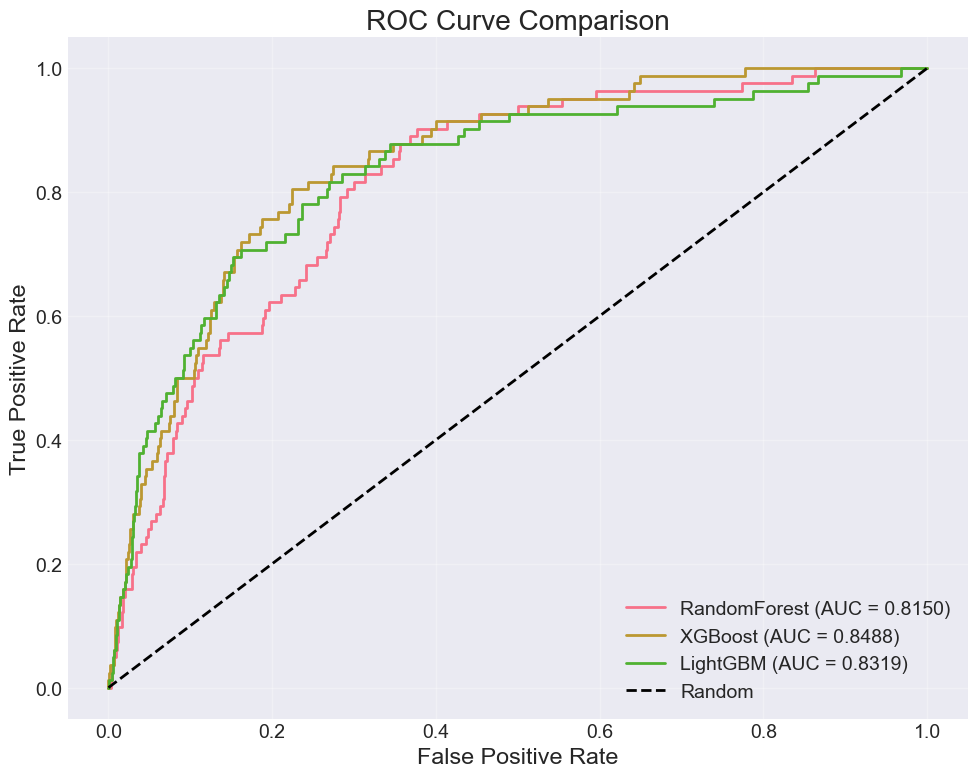


[7.2] Confusion Matrix
----------------------------------------
✅ Saved: outputs\confusion_matrix.png


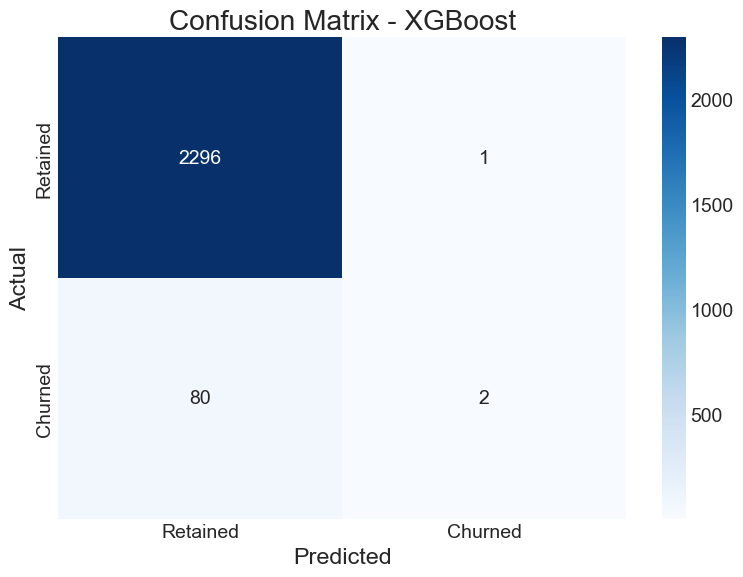


[7.3] Uplift Curves
----------------------------------------
✅ Saved: outputs\uplift_curves.png


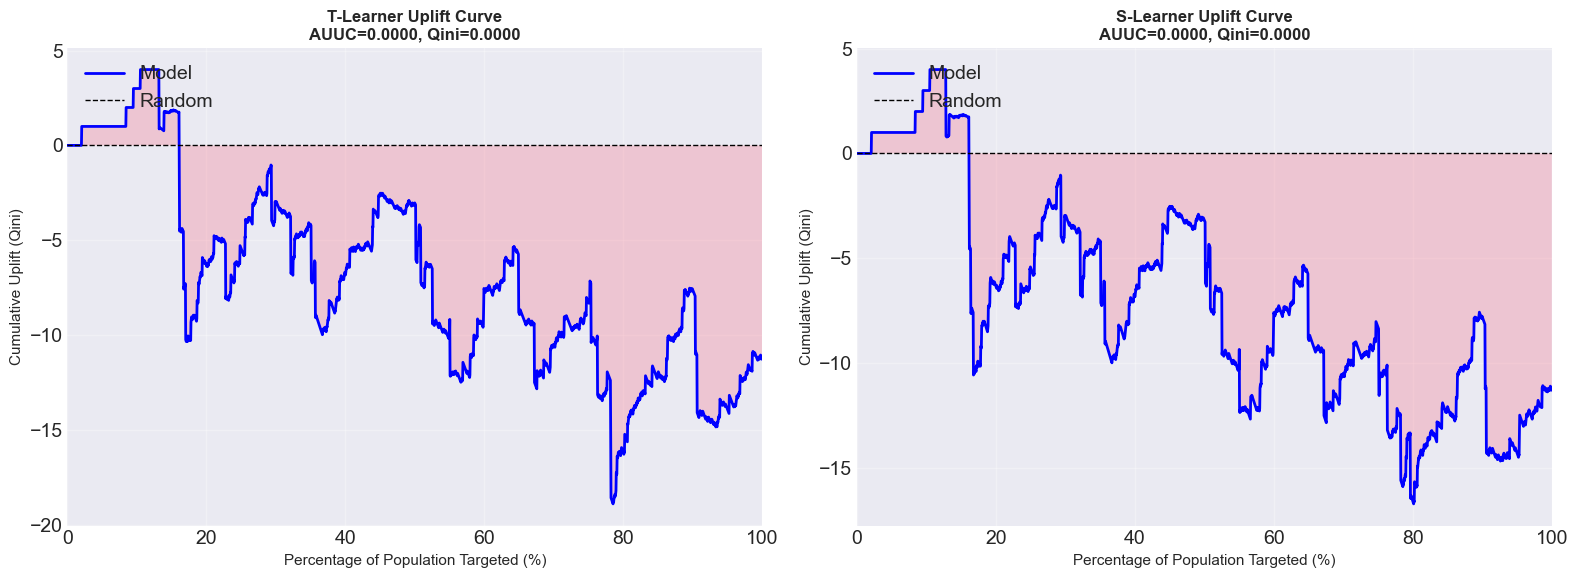

In [ ]:
# Create outputs directory
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

# 7.1 ROC Curves
print("\n[7.1] ROC Curves")
print("-" * 40)

fig, ax = plt.subplots(figsize=(10, 8))

for name, pred_proba in [('RandomForest', rf_pred_proba), 
                          ('XGBoost', xgb_pred_proba), 
                          ('LightGBM', lgb_pred_proba)]:
    fpr, tpr, _ = roc_curve(y_val, pred_proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / 'roc_curves.png', dpi=300, bbox_inches='tight')
print(f" Saved: {output_dir / 'roc_curves.png'}")
plt.show()
plt.close()

# 7.2 Confusion Matrix
print("\n[7.2] Confusion Matrix")
print("-" * 40)

best_pred = best_model.predict(X_val_scaled)
cm = confusion_matrix(y_val, best_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.savefig(output_dir / 'confusion_matrix.png', dpi=300, bbox_inches='tight')
print(f" Saved: {output_dir / 'confusion_matrix.png'}")
plt.show()
plt.close()

# 7.3 Uplift Curves
print("\n[7.3] Uplift Curves")
print("-" * 40)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Prepare data for plotting
uplift_t_flat = uplift_t.flatten() if len(uplift_t.shape) > 1 else uplift_t
uplift_s_flat = uplift_s.flatten() if len(uplift_s.shape) > 1 else uplift_s

# Manual uplift curve generation for T-Learner
def plot_uplift_curve(y_true, uplift_scores, treatment, ax, title):
    """
    Manually plot uplift curve (Qini curve)
    """
    # Sort by uplift score (descending)
    sorted_indices = np.argsort(-uplift_scores)
    y_sorted = y_true[sorted_indices]
    t_sorted = treatment[sorted_indices]
    
    # Calculate cumulative gains
    n = len(y_sorted)
    percentiles = np.arange(0, n+1)
    
    # Cumulative outcomes in treatment and control groups
    cum_treatment_outcomes = np.zeros(n+1)
    cum_control_outcomes = np.zeros(n+1)
    cum_treatment_size = np.zeros(n+1)
    cum_control_size = np.zeros(n+1)
    
    for i in range(n):
        if t_sorted[i] == 1:  # Treatment group
            cum_treatment_outcomes[i+1] = cum_treatment_outcomes[i] + y_sorted[i]
            cum_treatment_size[i+1] = cum_treatment_size[i] + 1
            cum_control_outcomes[i+1] = cum_control_outcomes[i]
            cum_control_size[i+1] = cum_control_size[i]
        else:  # Control group
            cum_control_outcomes[i+1] = cum_control_outcomes[i] + y_sorted[i]
            cum_control_size[i+1] = cum_control_size[i] + 1
            cum_treatment_outcomes[i+1] = cum_treatment_outcomes[i]
            cum_treatment_size[i+1] = cum_treatment_size[i]
    
    # Calculate Qini curve (cumulative uplift)
    # Qini = (outcomes_treatment / size_treatment) * size_treatment - (outcomes_control / size_control) * size_control
    qini_curve = np.zeros(n+1)
    for i in range(1, n+1):
        if cum_treatment_size[i] > 0 and cum_control_size[i] > 0:
            qini_curve[i] = cum_treatment_outcomes[i] - (cum_treatment_size[i] / cum_control_size[i]) * cum_control_outcomes[i]
    
    # Plot
    percentiles_pct = (percentiles / n) * 100
    ax.plot(percentiles_pct, qini_curve, 'b-', linewidth=2, label='Model')
    ax.plot([0, 100], [0, 0], 'k--', linewidth=1, label='Random')
    ax.fill_between(percentiles_pct, qini_curve, 0, alpha=0.3)
    
    ax.set_xlabel('Percentage of Population Targeted (%)', fontsize=11)
    ax.set_ylabel('Cumulative Uplift (Qini)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 100])

# Plot T-Learner
plot_uplift_curve(y_val, uplift_t_flat, t_val, axes[0], 
                  f'T-Learner Uplift Curve\nAUUC={auuc_t:.4f}, Qini={qini_t:.4f}')

# Plot S-Learner
plot_uplift_curve(y_val, uplift_s_flat, t_val, axes[1], 
                  f'S-Learner Uplift Curve\nAUUC={auuc_s:.4f}, Qini={qini_s:.4f}')

plt.tight_layout()
plt.savefig(output_dir / 'uplift_curves.png', dpi=300, bbox_inches='tight')
print(f" Saved: {output_dir / 'uplift_curves.png'}")
plt.show()
plt.close()

In [ ]:
print("\n" + "=" * 80)
print("SECTION 8: GENERATING RECOMMENDATIONS")
print("=" * 80)

churn_proba_val = best_model.predict_proba(X_val_scaled)[:, 1]

best_uplift_scores_flat = best_uplift_scores.flatten() if len(best_uplift_scores.shape) > 1 else best_uplift_scores # Flatten the array

recommendations = pd.DataFrame({
    'customer_index': range(len(X_val)),
    'churn_probability': churn_proba_val,
    'uplift_score': best_uplift_scores_flat,
    'actual_treatment': t_val,
    'actual_outcome': y_val
})

# Priority score
recommendations['priority_score'] = (
    recommendations['churn_probability'] * 0.6 + 
    recommendations['uplift_score'] * 0.4
)

# Assign interventions
def assign_intervention(row):
    if row['churn_probability'] > 0.7 and row['uplift_score'] > 0.05:
        return 'Premium_Support'
    elif row['churn_probability'] > 0.5 and row['uplift_score'] > 0.03:
        return 'Discount_20pct'
    elif row['uplift_score'] > 0.03:
        return 'Personalized_Outreach'
    elif row['churn_probability'] > 0.5:
        return 'Feature_Recommendation'
    else:
        return 'No_Action'

recommendations['recommended_intervention'] = recommendations.apply(assign_intervention, axis=1)
recommendations = recommendations.sort_values('priority_score', ascending=False)

print(f"Total customers: {len(recommendations):,}")
print(f"\nIntervention Distribution:")
print(recommendations['recommended_intervention'].value_counts())

# Save recommendations
recommendations.to_csv(output_dir / 'customer_recommendations.csv', index=False)
print(f"\n Recommendations saved: {output_dir / 'customer_recommendations.csv'}")

# Top 10
print("\n[8.1] TOP 10 PRIORITY CUSTOMERS")
print("-" * 40)
top_10 = recommendations.head(10)[
    ['customer_index', 'churn_probability', 'uplift_score', 
     'priority_score', 'recommended_intervention']
]
print(top_10.to_string(index=False))


SECTION 8: GENERATING RECOMMENDATIONS
Total customers: 2,379

Intervention Distribution:
recommended_intervention
No_Action                 2375
Feature_Recommendation       3
Personalized_Outreach        1
Name: count, dtype: int64

✅ Recommendations saved: outputs\customer_recommendations.csv

[8.1] TOP 10 PRIORITY CUSTOMERS
----------------------------------------
 customer_index  churn_probability  uplift_score  priority_score recommended_intervention
            451           0.340893           1.0        0.604536    Personalized_Outreach
           1104           0.654979           0.0        0.392987   Feature_Recommendation
            474           0.598769           0.0        0.359261   Feature_Recommendation
           2244           0.595201           0.0        0.357121   Feature_Recommendation
           1176           0.428680           0.0        0.257208                No_Action
           2374           0.386885           0.0        0.232131                No_Action

In [22]:
print("\n" + "=" * 80)
print("SECTION 9: FINAL TEST SET EVALUATION")
print("=" * 80)

# Churn prediction
print("\n[9.1] CHURN PREDICTION - TEST SET")
print("-" * 40)

test_churn_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# Check prediction distribution
print(f"\nPrediction probability distribution:")
print(f"  Min:    {test_churn_pred_proba.min():.4f}")
print(f"  Max:    {test_churn_pred_proba.max():.4f}")
print(f"  Mean:   {test_churn_pred_proba.mean():.4f}")
print(f"  Median: {np.median(test_churn_pred_proba):.4f}")

# Use optimal threshold from validation set instead of 0.5
# Find threshold that balances precision and recall
from sklearn.metrics import precision_recall_curve
precision_vals, recall_vals, thresholds = precision_recall_curve(y_val, 
                                                                  best_model.predict_proba(X_val_scaled)[:, 1])
# Find threshold where F1 is maximized
f1_scores = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-10)
optimal_threshold = thresholds[np.argmax(f1_scores)]

print(f"\nOptimal threshold (from validation): {optimal_threshold:.4f}")

# Apply optimal threshold
test_churn_pred = (test_churn_pred_proba >= optimal_threshold).astype(int)

# Check predictions
unique_preds, counts = np.unique(test_churn_pred, return_counts=True)
print(f"\nPrediction distribution:")
for pred, count in zip(unique_preds, counts):
    print(f"  Class {pred}: {count:>5,} ({count/len(test_churn_pred):.2%})")

test_auc = roc_auc_score(y_test, test_churn_pred_proba)
test_f1 = f1_score(y_test, test_churn_pred, zero_division=0)
test_precision = precision_score(y_test, test_churn_pred, zero_division=0)
test_recall = recall_score(y_test, test_churn_pred, zero_division=0)

print(f"\nFinal Test Performance ({best_model_name}):")
print(f"  AUC-ROC:   {test_auc:.4f} {'✅' if test_auc >= 0.85 else '⚠️'} (Target: ≥ 0.85)")
print(f"  F1-Score:  {test_f1:.4f} {'✅' if test_f1 >= 0.75 else '⚠️'} (Target: ≥ 0.75)")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")

# Uplift modeling
print("\n[9.2] UPLIFT MODELING - TEST SET")
print("-" * 40)

test_uplift = best_uplift_model.predict(X_test_scaled)

# Flatten if needed
test_uplift_flat = test_uplift.flatten() if len(test_uplift.shape) > 1 else test_uplift

print(f"\nTest set treatment distribution:")
print(f"  Control (t=0): {(t_test == 0).sum():>5,} ({(t_test == 0).mean():.2%})")
print(f"  Treated (t=1): {(t_test == 1).sum():>5,} ({(t_test == 1).mean():.2%})")

print(f"\nTest uplift statistics:")
print(f"  Mean:   {test_uplift_flat.mean():.4f}")
print(f"  Std:    {test_uplift_flat.std():.4f}")
print(f"  Min:    {test_uplift_flat.min():.4f}")
print(f"  Max:    {test_uplift_flat.max():.4f}")

# Check if we have both treatment groups
if (t_test == 0).sum() > 0 and (t_test == 1).sum() > 0:
    # Create DataFrame for CausalML
    df_test = pd.DataFrame({
        'y': y_test,
        't': t_test,
        'uplift': test_uplift_flat
    })

    try:
        test_auuc = auuc_score(df_test, outcome_col='y', treatment_col='t', treatment_effect_col='uplift')
        print(f"\n✅ AUUC calculated successfully")
    except Exception as e:
        print(f"\n⚠️  AUUC calculation issue: {str(e)[:100]}")
        test_auuc = 0.0

    try:
        test_qini = qini_score(df_test, outcome_col='y', treatment_col='t', treatment_effect_col='uplift')
        print(f"✅ Qini calculated successfully")
    except Exception as e:
        print(f"⚠️  Qini calculation issue: {str(e)[:100]}")
        test_qini = 0.0
else:
    print("\n⚠️  Warning: Test set doesn't have both treatment groups!")
    print("   Cannot calculate AUUC/Qini metrics")
    test_auuc = 0.0
    test_qini = 0.0

print(f"\nFinal Test Performance ({best_uplift_name}):")
print(f"  AUUC:       {test_auuc:.4f}")
print(f"  Qini Coeff: {test_qini:.4f} {'✅' if test_qini > 0.1 else '⚠️'} (Target: > 0.1)")


SECTION 9: FINAL TEST SET EVALUATION

[9.1] CHURN PREDICTION - TEST SET
----------------------------------------

Prediction probability distribution:
  Min:    0.0001
  Max:    0.7590
  Mean:   0.0128
  Median: 0.0033

Optimal threshold (from validation): 0.0613

Prediction distribution:
  Class 0: 2,274 (95.55%)
  Class 1:   106 (4.45%)

Final Test Performance (XGBoost):
  AUC-ROC:   0.8386 ⚠️ (Target: ≥ 0.85)
  F1-Score:  0.2553 ⚠️ (Target: ≥ 0.75)
  Precision: 0.2264
  Recall:    0.2927

[9.2] UPLIFT MODELING - TEST SET
----------------------------------------

Test set treatment distribution:
  Control (t=0):   543 (22.82%)
  Treated (t=1): 1,837 (77.18%)

Test uplift statistics:
  Mean:   0.0004
  Std:    0.0205
  Min:    0.0000
  Max:    1.0000

⚠️  AUUC calculation issue: No objects to concatenate
⚠️  Qini calculation issue: No objects to concatenate

Final Test Performance (T-Learner):
  AUUC:       0.0000
  Qini Coeff: 0.0000 ⚠️ (Target: > 0.1)
